# CompassIQ Dataset Visualization

This notebook explores the historical customer-support dataset used by CompassIQ. It is read-only and does not modify the source CSV.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path('compassiq/data/enhanced_customer_support_data.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('../compassiq/data/enhanced_customer_support_data.csv')

df = pd.read_csv(DATA_PATH)
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)
print(f'Loaded {len(df):,} rows from {DATA_PATH}')

Loaded 20,000 rows from compassiq\data\enhanced_customer_support_data.csv


## Dataset overview

In [2]:
display(df.head())
print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.dtypes.rename('dtype').to_frame())
display(df.isna().sum().rename('missing_values').to_frame())
print('Duplicate rows:', df.duplicated().sum())
display(df.describe(include='all').T)

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


Shape: (20000, 12)
Columns: ['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']


,dtype
Ticket_ID,object
Customer_Name,object
Customer_Email,object
Ticket_Subject,object
Ticket_Description,object
Issue_Category,object
Priority_Level,object
Ticket_Channel,object
Submission_Date,object
Resolution_Time_Hours,int64


,missing_values
Ticket_ID,0
Customer_Name,0
Customer_Email,0
Ticket_Subject,0
Ticket_Description,0
Issue_Category,0
Priority_Level,0
Ticket_Channel,0
Submission_Date,0
Resolution_Time_Hours,0


Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket_ID,20000,20000,TKT-100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,20000,17900,William Smith,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Email,20000,19489,njohnson@example.com,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Subject,20000,13943,Login failed - Ever,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Description,20000,20000,"Hi Support, Where is your headquarters located...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue_Category,20000,5,Technical,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Priority_Level,20000,4,Low,7716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket_Channel,20000,3,Chat,6693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Submission_Date,20000,731,2025-05-11,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Resolution_Time_Hours,20000.0,NaN,NaN,NaN,39.2303,35.221884,1.0,11.0,27.0,58.0,120.0


## Category and priority distributions

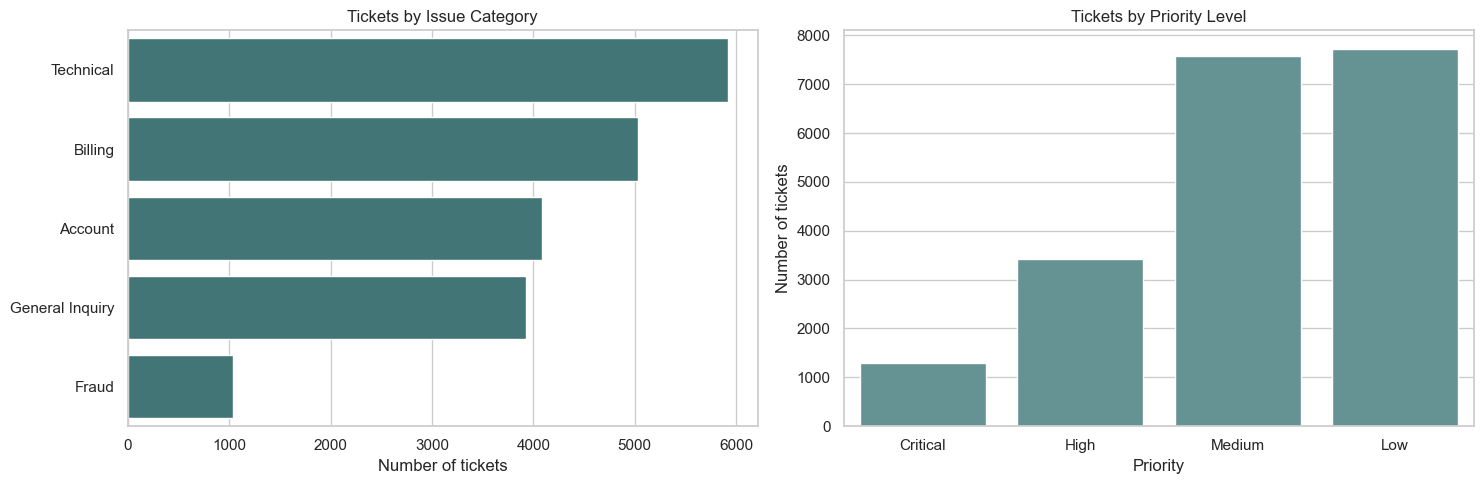

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, y='Issue_Category', order=df['Issue_Category'].value_counts().index, ax=axes[0], color='#397d7f')
axes[0].set_title('Tickets by Issue Category')
axes[0].set_xlabel('Number of tickets')
axes[0].set_ylabel('')
sns.countplot(data=df, x='Priority_Level', order=['Critical', 'High', 'Medium', 'Low'], ax=axes[1], color='#5d999a')
axes[1].set_title('Tickets by Priority Level')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Number of tickets')
plt.tight_layout()
plt.show()

## Ticket channels and monthly volume

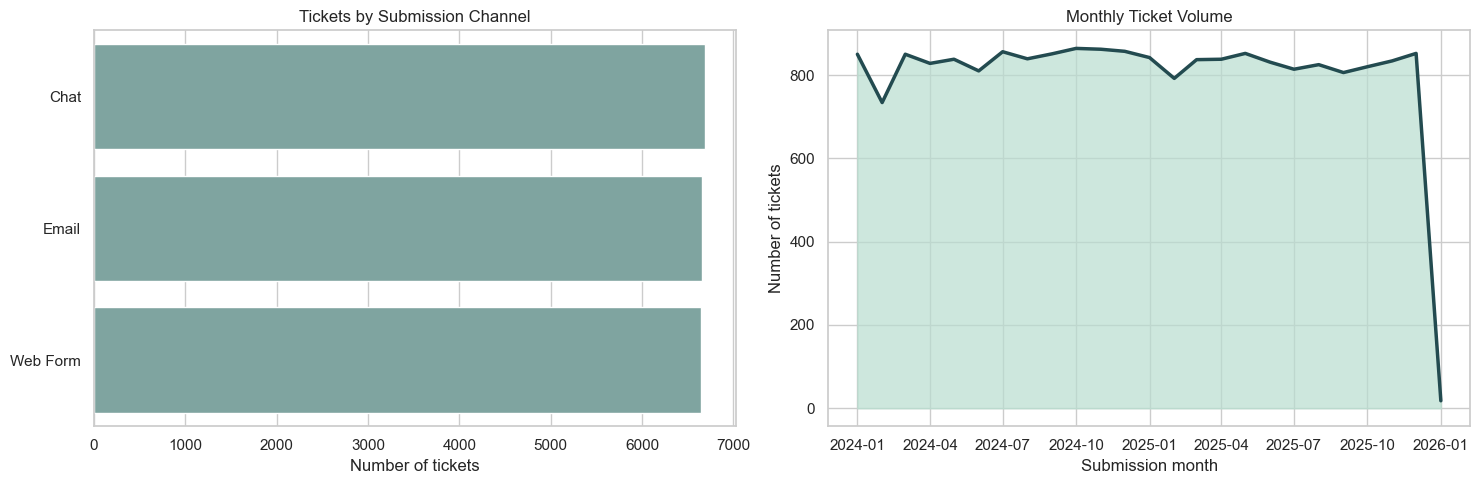

In [4]:
df['Submission_Date'] = pd.to_datetime(df['Submission_Date'], errors='coerce')
monthly_volume = df.dropna(subset=['Submission_Date']).set_index('Submission_Date').resample('MS').size()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
channel_order = df['Ticket_Channel'].value_counts().index
sns.countplot(data=df, y='Ticket_Channel', order=channel_order, ax=axes[0], color='#79aaa5')
axes[0].set_title('Tickets by Submission Channel')
axes[0].set_xlabel('Number of tickets')
axes[0].set_ylabel('')
axes[1].plot(monthly_volume.index, monthly_volume.values, color='#234b50', linewidth=2.5)
axes[1].fill_between(monthly_volume.index, monthly_volume.values, color='#b9ddcf', alpha=0.7)
axes[1].set_title('Monthly Ticket Volume')
axes[1].set_xlabel('Submission month')
axes[1].set_ylabel('Number of tickets')
plt.tight_layout()
plt.show()

## Resolution time and satisfaction

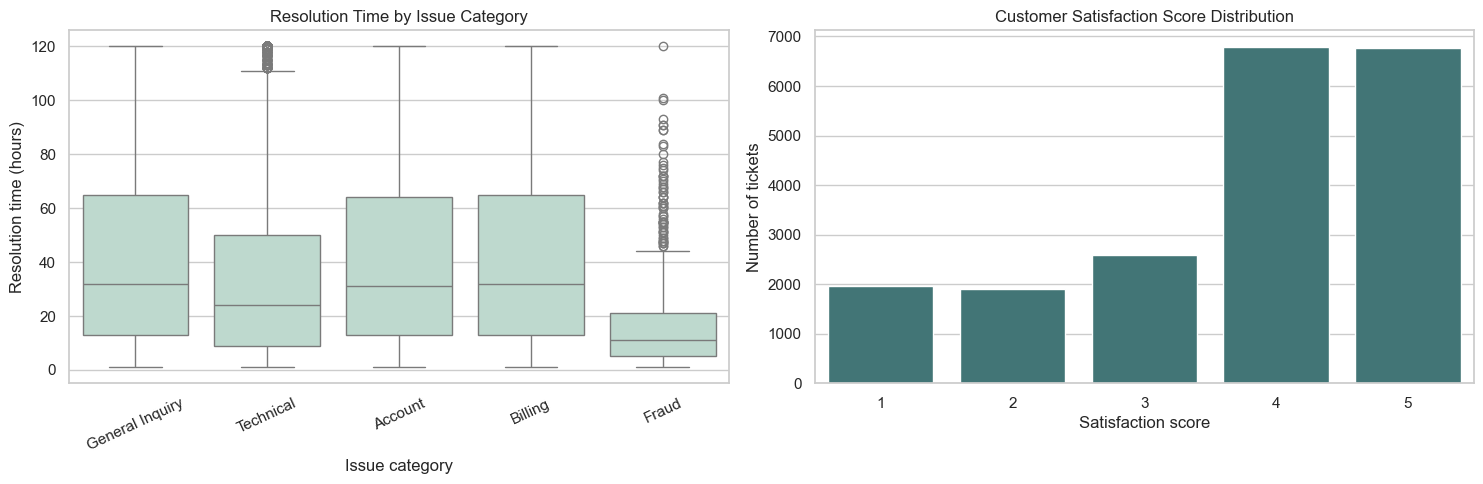

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='Issue_Category', y='Resolution_Time_Hours', ax=axes[0], color='#b9ddcf')
axes[0].set_title('Resolution Time by Issue Category')
axes[0].set_xlabel('Issue category')
axes[0].set_ylabel('Resolution time (hours)')
axes[0].tick_params(axis='x', rotation=25)
sns.countplot(data=df, x='Satisfaction_Score', order=sorted(df['Satisfaction_Score'].dropna().unique()), ax=axes[1], color='#397d7f')
axes[1].set_title('Customer Satisfaction Score Distribution')
axes[1].set_xlabel('Satisfaction score')
axes[1].set_ylabel('Number of tickets')
plt.tight_layout()
plt.show()

## Category and priority relationship

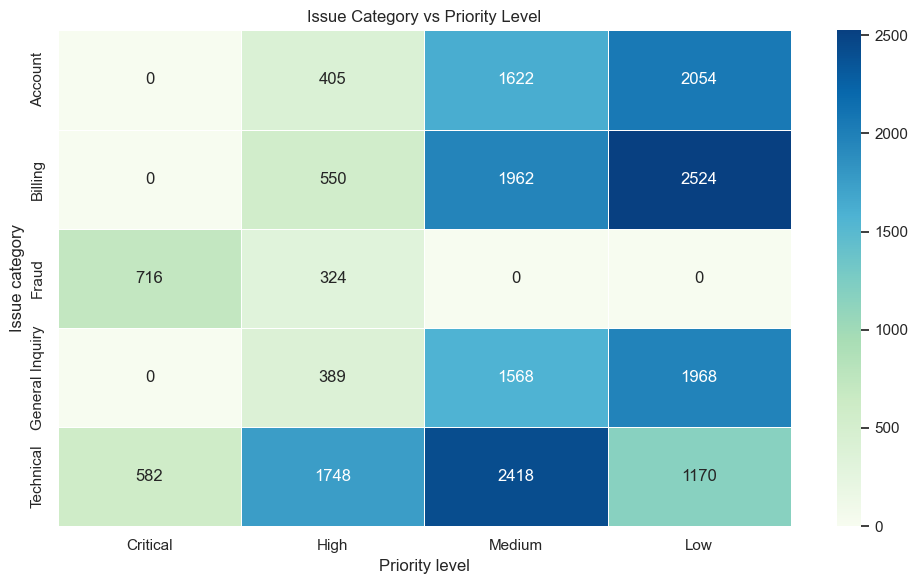

In [6]:
category_priority = pd.crosstab(df['Issue_Category'], df['Priority_Level'])
category_priority = category_priority.reindex(columns=['Critical', 'High', 'Medium', 'Low'], fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(category_priority, annot=True, fmt='d', cmap='GnBu', linewidths=0.5)
plt.title('Issue Category vs Priority Level')
plt.xlabel('Priority level')
plt.ylabel('Issue category')
plt.tight_layout()
plt.show()

## Summary observations

In [7]:
print('Most common category:', df['Issue_Category'].mode().iat[0])
print('Most common priority:', df['Priority_Level'].mode().iat[0])
print('Most common channel:', df['Ticket_Channel'].mode().iat[0])
print('Average resolution time:', round(df['Resolution_Time_Hours'].mean(), 2), 'hours')
print('Average satisfaction score:', round(df['Satisfaction_Score'].mean(), 2))
print('These distributions can guide model evaluation, routing analysis, and dashboard design.')

Most common category: Technical
Most common priority: Low
Most common channel: Chat
Average resolution time: 39.23 hours
Average satisfaction score: 3.72
These distributions can guide model evaluation, routing analysis, and dashboard design.
